<div style="background:#111A33;border-radius:14px;padding:26px 30px;border-left:6px solid #E5484D">
<div style="color:#F5A623;font-size:13px;letter-spacing:3px;font-weight:700">SESSION 9 &nbsp;&middot;&nbsp; WEEK 5 &nbsp;&middot;&nbsp; SQL FUNDAMENTALS</div>
<div style="color:#FFFFFF;font-size:34px;font-weight:800;line-height:1.15;margin-top:8px">SQL Core Concepts</div>
<div style="color:#C7CEDB;font-size:16px;margin-top:6px">SELECT &middot; WHERE &middot; ORDER BY &middot; GROUP BY &middot; HAVING</div>
<div style="background:#F5A623;color:#111A33;display:inline-block;padding:5px 14px;border-radius:6px;font-weight:700;font-size:12px;letter-spacing:1px;margin-top:16px">MODERN DATA ENGINEERING &nbsp;|&nbsp; DEPTHWARE</div>
</div>

### What you'll be able to do by the end

By the end of this session you can open a dataset and **ask it questions** in SQL: pick the columns you care about, filter to the rows that matter, sort them, and roll thousands of rows up into a handful of meaningful numbers — total revenue, rides per driver, averages per group.

We run everything **locally, with zero setup** — no database server, no cloud account, no Docker. Just one Python library called **DuckDB** that runs SQL right here inside the notebook. The SQL you learn is standard, so it carries straight over to BigQuery later in the course.

> **Prereqs:** Sessions 1–4 (Python + Pandas). If you can read a DataFrame, you're ready.

---
## 1 &middot; The big idea: SQL is *describing what you want*

Imagine you walk up to a librarian with a request slip:

> *"Give me the **title and author** of every **history book published after 2000**, **grouped by decade** with a count, **sorted newest first**, and just the **top 5**."*

You didn't tell the librarian *how* to walk the aisles or *which* shelf to check first. You described the **result you want**, and they figure out how to fetch it. That's exactly what SQL is — a **declarative** language. You describe the answer; the database works out the *how*.

And every part of that request slip is a clause you'll learn today:

| Your request slip | SQL clause | What it decides |
|---|---|---|
| "the title and author…" | `SELECT` | **which columns** come back |
| "…history books after 2000" | `WHERE` | **which rows** qualify |
| "grouped by decade with a count" | `GROUP BY` | **collapse rows into groups** |
| "sorted newest first" | `ORDER BY` | **the order** of the result |
| "just the top 5" | `LIMIT` | **how many** rows |

That's the whole session. Five ideas, one request slip.

---
## 2 &middot; You already know this (from Pandas)

You spent four sessions in Pandas. Here's the secret: **SQL is the same ideas in a different language.** A DataFrame *is* a table. The things you did to DataFrames have direct SQL twins:

| What you want | Pandas (Sessions 3–4) | SQL (today) |
|---|---|---|
| Pick columns | `df[["fare","status"]]` | `SELECT fare, status` |
| Filter rows | `df[df["fare"] > 200]` | `WHERE fare > 200` |
| Sort | `df.sort_values("fare", ascending=False)` | `ORDER BY fare DESC` |
| First N rows | `df.head(10)` | `LIMIT 10` |
| Group + aggregate | `df.groupby("status").size()` | `GROUP BY status` + `COUNT(*)` |

So you're not starting from zero — you're translating instincts you already have.

---
## 3 &middot; Meet the dataset

We'll work with data from a fictional ride-hailing company operating across five Turkish cities. It comes as four CSV files that live in a `data/` folder next to this notebook. Four tables, connected by **keys** (shared ID columns):
<p align="center">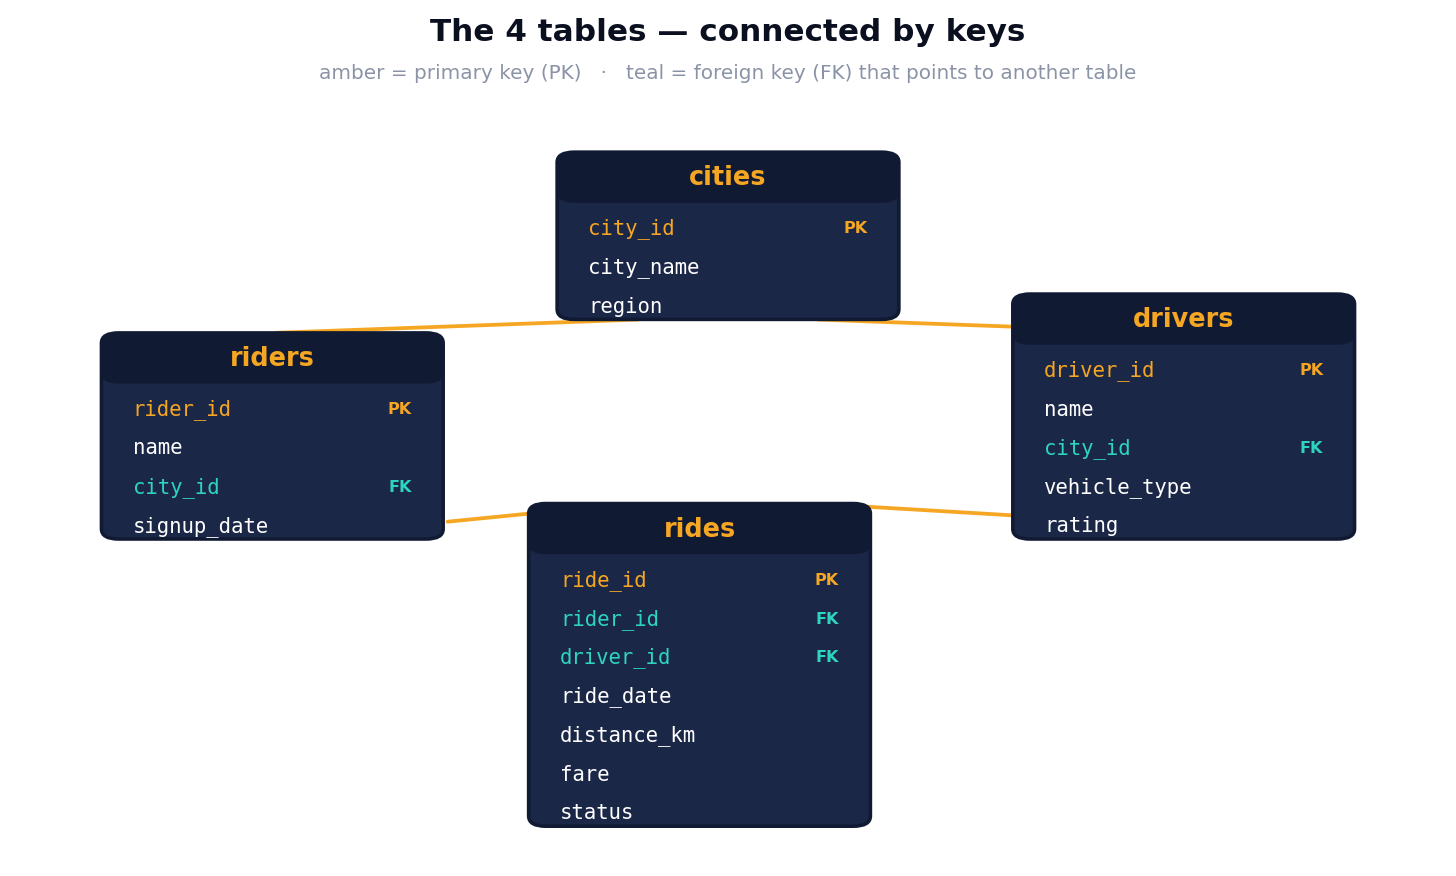</p>

A few things to notice now — they'll matter later:

- **`rides`** is the big one (1,200 rows). The other three are small **lookup** tables.
- A **primary key (PK)** uniquely identifies a row (`rides.ride_id`). A **foreign key (FK)** points at another table's PK (`rides.rider_id` → `riders.rider_id`).
- Some cells are **empty on purpose** — a couple of riders never set a city, and cancelled rides have no driver or fare. Empty cells become `NULL` in SQL, and we'll learn to handle them.

Today we mostly work **inside one table at a time**. *Connecting* the tables (so you can ask "revenue per **city**") is the whole point of Session 10.

---
## 4 &middot; Setup — load the data into DuckDB

DuckDB runs **in-process**: it's just a Python import, like Pandas. No server to start, nothing to install beyond `pip install duckdb`. We open a connection and register each CSV as a table.

In [1]:
import duckdb
import pandas as pd

pd.set_option("display.max_rows", 20)

# An in-memory DuckDB connection — lives only while the notebook runs.
con = duckdb.connect("rides.duckdb")

# Register each CSV as a queryable table.
for table in ["cities", "drivers", "riders", "rides"]:
    con.sql(f"""
        CREATE TABLE {table} AS
        SELECT * FROM read_csv('data/{table}.csv', header = true)
    """)

print("Tables loaded:", [r[0] for r in con.sql("SHOW TABLES").fetchall()])

Tables loaded: ['cities', 'drivers', 'riders', 'rides']


Throughout the notebook we'll wrap queries in a tiny helper, `q()`, that runs the SQL and hands back a DataFrame so results render as a clean table. **The SQL inside the string is the part that matters** — `q()` is just for display.

In [4]:
def q(sql):
    """Run a SQL string and return the result as a pandas DataFrame."""
    return con.sql(sql).df()

# The lookup tables are small enough to view in full:
q("SELECT * FROM cities")
# q("SELECT * FROM riders")

,city_id,city_name,region
0,1,Istanbul,Marmara
1,2,Ankara,Central Anatolia
2,3,Izmir,Aegean
3,4,Bursa,Marmara
4,5,Antalya,Mediterranean


In [34]:
# A peek at the big table (LIMIT keeps the output readable):
q("SELECT * FROM rides LIMIT 15")

,ride_id,rider_id,driver_id,ride_date,distance_km,fare,status
0,1,63,24,2025-01-14,20.6,310.55,completed
1,2,91,47,2025-01-20,17.1,325.42,completed
2,3,79,30,2025-03-10,14.4,171.42,completed
3,4,35,6,2025-02-11,9.5,119.27,completed
4,5,60,25,2025-03-14,11.3,137.24,completed
5,6,42,23,2025-01-24,25.7,466.28,completed
6,7,77,36,2025-03-31,1.1,49.41,completed
7,8,11,32,2025-01-31,18.1,265.54,completed
8,9,61,29,2025-03-24,25.5,457.91,completed
9,10,29,20,2025-02-21,21.5,231.63,completed


---
## 5 &middot; `SELECT` — choosing columns

`SELECT` decides **which columns** appear in your result. `*` means "every column". You can also rename a column in the output with `AS` (an *alias*), drop duplicates with `DISTINCT`, and cap the rows with `LIMIT`.

In [5]:
# Just the columns we care about, renamed for readability, top 5 rows.
q("""
    SELECT ride_id,
           distance_km AS km,
           fare AS fare_try
    FROM rides
    LIMIT 5
""")

,ride_id,km,fare_try
0,1,20.6,310.55
1,2,17.1,325.42
2,3,14.4,171.42
3,4,9.5,119.27
4,5,11.3,137.24


In [7]:
# DISTINCT — the unique values in a column. How many vehicle types exist?
q("SELECT DISTINCT vehicle_type FROM drivers")

,vehicle_type
0,comfort
1,xl
2,economy


---
## 6 &middot; `WHERE` — filtering rows

`WHERE` keeps only the rows that make a condition **true**. This is the SQL twin of `df[df["fare"] > 200]`. You can combine conditions with `AND` / `OR`, and a few keywords make common filters readable:

- `IN (...)` — matches any value in a list
- `BETWEEN a AND b` — inclusive range
- `LIKE` — text pattern matching (`%` = any characters)
- `IS NULL` / `IS NOT NULL` — the **only** correct way to test for an empty value

In [38]:
# Completed rides longer than 25 km, costing more than 300 TRY.
q("""
    SELECT ride_id, distance_km, fare, status
    FROM rides
    WHERE status = 'completed'
      AND distance_km > 25
      AND fare > 300
    LIMIT 8
""")

,ride_id,distance_km,fare,status
0,6,25.7,466.28,completed
1,9,25.5,457.91,completed
2,20,30.4,426.02,completed
3,27,25.4,370.32,completed
4,30,29.5,421.13,completed
5,31,30.2,316.91,completed
6,34,32.0,337.45,completed
7,36,29.4,526.37,completed


In [8]:
# IN and BETWEEN: economy or xl drivers, rated between 4.5 and 5.0.
q("""
    SELECT name, vehicle_type, rating
    FROM drivers
    WHERE vehicle_type IN ('economy', 'xl')
      AND rating BETWEEN 4.5 AND 5.0
    LIMIT 12
""")

,name,vehicle_type,rating
0,Buse Aslan,xl,4.5
1,Buse Celik,economy,4.6
2,Buse Kurt,xl,4.8
3,Gizem Yilmaz,xl,4.8
4,Gizem Ozturk,economy,4.9
5,Derya Yildiz,economy,4.8
6,Burak Kara,economy,4.5
7,Melis Yilmaz,xl,4.8
8,Kaan Cetin,economy,4.8


**The `NULL` trap.** Remember those riders who never set a city? Their `city_id` is empty — `NULL`. You **cannot** find them with `= NULL` (that's never true). You must use `IS NULL`:

In [40]:
# Riders with no city on file. Note: IS NULL, never = NULL.
q("SELECT rider_id, name, city_id FROM riders WHERE city_id IS NULL")

,rider_id,name,city_id
0,37,Elif Ozdemir,<NA>
1,88,Melis Kaya,<NA>


---
## 7 &middot; `ORDER BY` — sorting the result

`ORDER BY` sorts rows: `ASC` for smallest-first (the default), `DESC` for largest-first. Combine with `LIMIT` and you get the classic **"top N"** query.

In [10]:
# The 5 most expensive completed rides.
q("""
    SELECT ride_id, distance_km, fare
    FROM rides
    WHERE status = 'completed'
    ORDER BY fare DESC
    LIMIT 5
""")

,ride_id,distance_km,fare
0,876,31.8,577.68
1,373,31.9,575.15
2,890,31.1,570.00
3,589,31.5,562.87
4,1030,30.5,554.31


In [11]:
# Sort by more than one column: best-rated drivers, breaking ties by name.
q("""
    SELECT name, vehicle_type, rating
    FROM drivers
    ORDER BY rating DESC, name ASC
    LIMIT 6
""")

,name,vehicle_type,rating
0,Yusuf Demir,comfort,5.0
1,Gizem Ozturk,economy,4.9
2,Melis Celik,comfort,4.9
3,Buse Kurt,xl,4.8
4,Derya Yildiz,economy,4.8
5,Gizem Yilmaz,xl,4.8


---
## 8 &middot; Aggregate functions — turning many rows into one number

Sometimes you don't want rows back — you want a **summary**: a count, a total, an average. That's what aggregate functions do:

| Function | Answers |
|---|---|
| `COUNT(*)` | how many rows? |
| `COUNT(col)` | how many **non-NULL** values in `col`? |
| `SUM(col)` | total |
| `AVG(col)` | average |
| `MIN(col)` / `MAX(col)` | smallest / largest |

One subtlety worth burning in: **aggregates ignore `NULL`.** Watch what happens with our cancelled rides, which have no fare:

In [16]:
# COUNT(*) counts every row. COUNT(fare) skips the NULL (cancelled) fares.
q("""
    SELECT COUNT(*)        AS total_rides,
           COUNT(fare)     AS rides_with_fare,
           ROUND(SUM(fare), 0)  AS total_revenue,
           ROUND(AVG(fare), 2)  AS avg_fare,
           MAX(fare)            AS biggest_fare,
           MIN(fare)             AS smallest_fare
    FROM rides
""")

,total_rides,rides_with_fare,total_revenue,avg_fare,biggest_fare,smallest_fare
0,1200,1076,240522.0,223.53,577.68,28.08


`total_rides` is 1200 but `rides_with_fare` is 1076 — the gap is the 124 cancelled rides whose fare is `NULL`. And critically, `avg_fare` divided by **1076, not 1200**. If you forget that NULLs are skipped, your averages will silently lie to you.

---
## 9 &middot; `GROUP BY` — the conceptual leap

So far an aggregate gave us **one number for the whole table**. `GROUP BY` is the upgrade: it splits rows into groups by some column, then gives you **one summary row per group**.
<p align="center">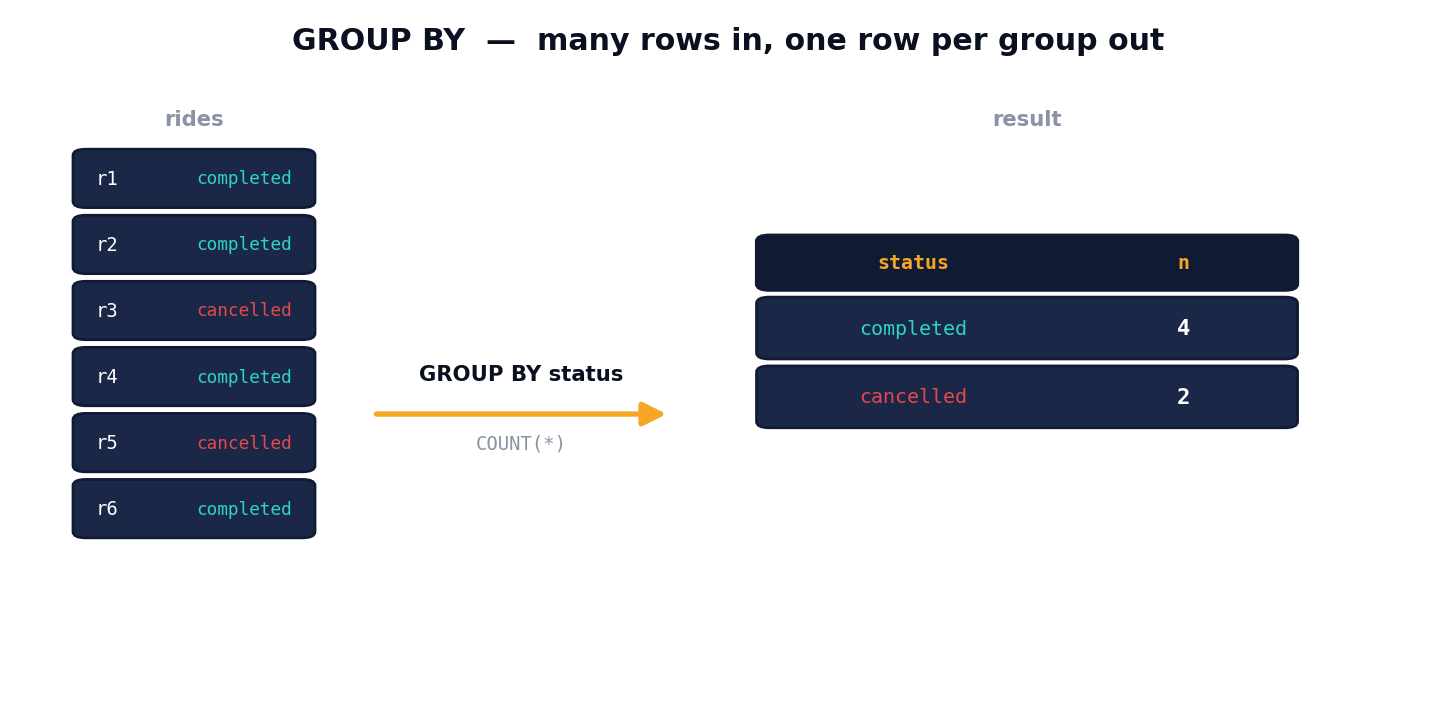</p>

The mental model: *every column in your `SELECT` must either be in the `GROUP BY`, or wrapped in an aggregate.* If it isn't one of those two things, SQL won't know which value to show for the group.

In [18]:
# How many rides of each status, and the revenue each represents?
q("""
    SELECT status,
           COUNT(*)            AS rides,
           ROUND(SUM(fare), 0) AS revenue,
           MAX(fare)           AS max_fare
    FROM rides
    GROUP BY status
""")

,status,rides,revenue,max_fare
0,cancelled,124,NaN,NaN
1,completed,1076,240522.0,577.68


In [19]:
# Rides and revenue per driver — the busiest 6 by revenue.
q("""
    SELECT driver_id,
           COUNT(*)            AS rides,
           ROUND(SUM(fare), 0) AS revenue
    FROM rides
    WHERE status = 'completed'
    GROUP BY driver_id
    ORDER BY revenue DESC
    LIMIT 6
""")

,driver_id,rides,revenue
0,29,33,10845.0
1,14,23,8494.0
2,21,31,7495.0
3,37,24,7175.0
4,33,27,6521.0
5,50,29,6487.0


Notice we grouped by `driver_id` — a number. We can't yet show the driver's **name** or **city**, because those live in *other tables*. Holding that thought is exactly what Session 10 (joins) is for.

---
## 10 &middot; `HAVING` — filtering the groups

Here's a question students always trip on: *"how do I filter on a `COUNT`?"* You can't use `WHERE` — `WHERE` filters **individual rows before grouping**, and the count doesn't exist yet at that point. You need `HAVING`, which filters **groups after aggregating**.

> **`WHERE` filters rows. `HAVING` filters groups.** That one line resolves 90% of the confusion.

In [ ]:
# Drivers who completed MORE THAN 30 rides — a per-group filter, so HAVING.
q("""
    SELECT driver_id,
           COUNT(*)            AS rides,
           ROUND(SUM(fare), 0) AS revenue
    FROM rides
    WHERE status = 'completed'      -- filters rows  (before grouping)
    GROUP BY driver_id
    HAVING COUNT(*) > 30            -- filters groups (after grouping)
    ORDER BY rides DESC
""")

,driver_id,rides,revenue
0,29,33,10845.0
1,21,31,7495.0
2,45,29,5623.0
3,27,29,5029.0
4,50,29,6487.0
...,...,...,...
45,20,15,3059.0
46,39,15,2524.0
47,16,14,2039.0
48,18,14,2719.0


In [23]:
con.sql(f"""
        CREATE TABLE completed_rides_per_driver AS
            SELECT driver_id,
           COUNT(*)            AS rides,
           ROUND(SUM(fare), 0) AS revenue
    FROM rides
    WHERE status = 'completed'      -- filters rows  (before grouping)
    GROUP BY driver_id
    """)

In [24]:
con.sql("SELECT * FROM completed_rides_per_driver")

┌───────────┬───────┬─────────┐
│ driver_id │ rides │ revenue │
│   int64   │ int64 │ double  │
├───────────┼───────┼─────────┤
│         1 │    14 │  2716.0 │
│         2 │    19 │  2853.0 │
│         3 │    18 │  3624.0 │
│         4 │    18 │  3750.0 │
│         5 │    20 │  3366.0 │
│         6 │    22 │  3972.0 │
│         7 │    22 │  6251.0 │
│         8 │    21 │  4184.0 │
│         9 │    20 │  3522.0 │
│        10 │    22 │  4479.0 │
│         · │     · │     ·   │
│         · │     · │     ·   │
│         · │     · │     ·   │
│        41 │    26 │  4986.0 │
│        42 │    17 │  5023.0 │
│        43 │    23 │  5593.0 │
│        44 │    23 │  4690.0 │
│        45 │    29 │  5623.0 │
│        46 │    23 │  4418.0 │
│        47 │    18 │  6051.0 │
│        48 │    22 │  4817.0 │
│        49 │    20 │  4224.0 │
│        50 │    29 │  6487.0 │
└───────────┴───────┴─────────┘
  50 rows (20 shown)3 columns

---
## 11 &middot; Why order matters: how SQL *runs* a query

You write `SELECT` first — but SQL doesn't *run* it first. The engine processes clauses in a fixed logical order, and knowing it explains nearly every "why doesn't this work?" moment:
<p align="center">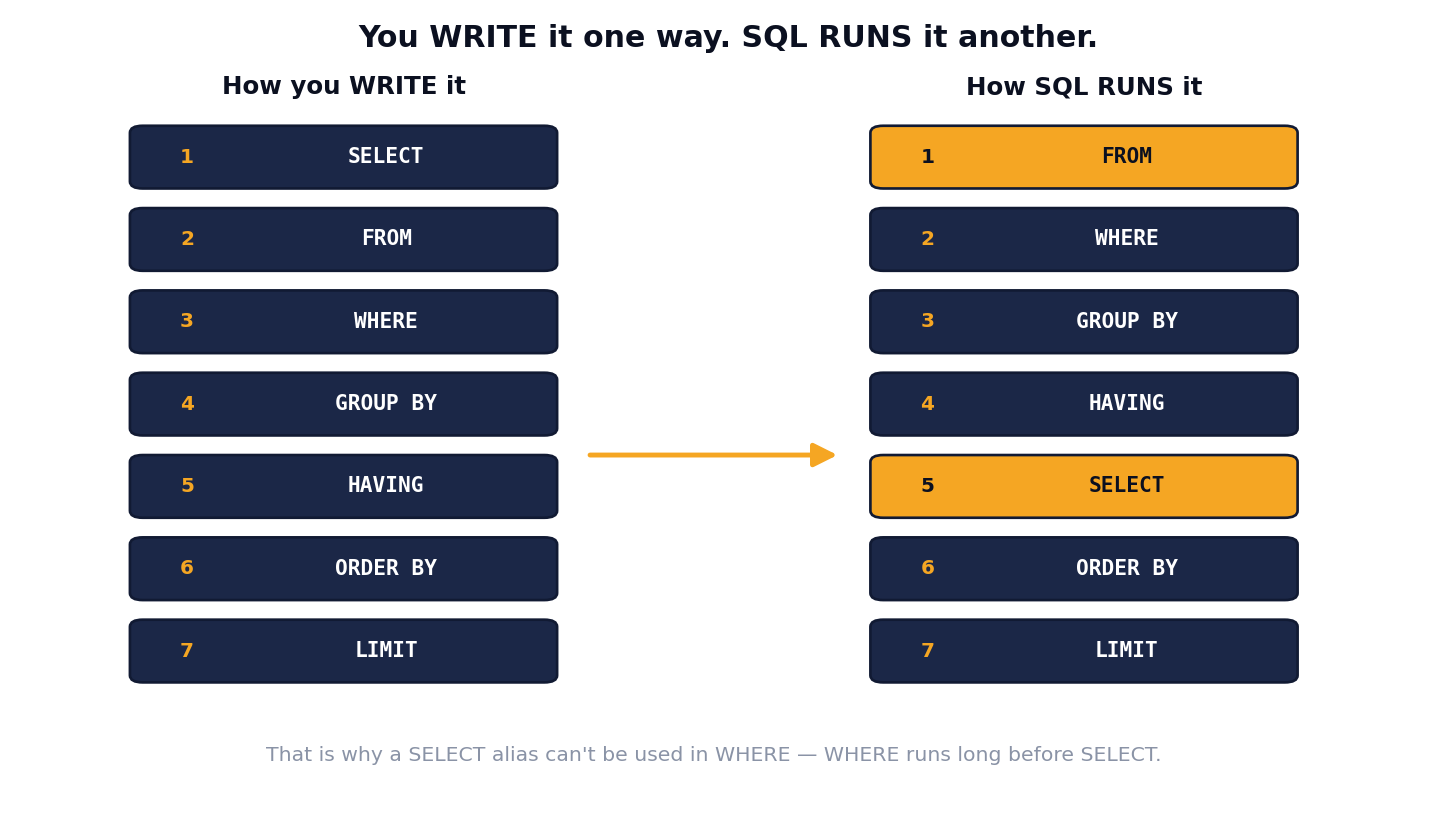</p>

Read the right-hand column top to bottom — that's the real sequence. `FROM` grabs the table, `WHERE` filters rows, `GROUP BY` forms groups, `HAVING` filters those groups, **then** `SELECT` picks columns, and finally `ORDER BY` and `LIMIT` arrange and trim. This is why a name you create in `SELECT` (an alias) can't be used back in `WHERE` — `WHERE` already ran.

Here's a query that uses every clause at once. Read it in **execution order** and it tells a clean story:

In [ ]:
# Every clause working together: top 5 drivers by revenue,
# among drivers who completed at least 25 rides.
q("""
    SELECT driver_id,
           COUNT(*)            AS rides,
           ROUND(SUM(fare), 0) AS revenue,
           ROUND(AVG(fare), 2) AS avg_fare
    FROM rides                       -- 1. take the rides table
    WHERE status = 'completed'       -- 2. keep only completed rides
    GROUP BY driver_id               -- 3. one group per driver
    HAVING COUNT(*) >= 25            -- 4. keep busy drivers only
    ORDER BY revenue DESC            -- 5. richest first
    LIMIT 5                          -- 6. just the top 5
""")

---
## 12 &middot; Pandas &harr; SQL cheat sheet

Keep this nearby. Anything you can do in one, you can usually do in the other:

| Task | Pandas | SQL |
|---|---|---|
| All columns | `df` | `SELECT * FROM t` |
| Some columns | `df[["a","b"]]` | `SELECT a, b FROM t` |
| Rename | `df.rename(columns={"a":"x"})` | `SELECT a AS x` |
| Unique values | `df["a"].unique()` | `SELECT DISTINCT a` |
| Filter | `df[df.a > 5]` | `WHERE a > 5` |
| Filter on a list | `df[df.a.isin([1,2])]` | `WHERE a IN (1, 2)` |
| Missing values | `df[df.a.isna()]` | `WHERE a IS NULL` |
| Sort | `df.sort_values("a", ascending=False)` | `ORDER BY a DESC` |
| Top N | `df.head(10)` | `LIMIT 10` |
| Count rows | `len(df)` | `SELECT COUNT(*)` |
| Group + aggregate | `df.groupby("a")["b"].sum()` | `SELECT a, SUM(b) ... GROUP BY a` |
| Filter on aggregate | `.groupby(...).filter(...)` | `HAVING ...` |

---
## 13 &middot; Your turn — exercises

Run these against the **full** dataset. Try each one before opening the solution. Write your query in the empty cell, then check yourself.

**Exercise 1 — `SELECT` + `WHERE` + `ORDER BY`**
List the `ride_id`, `distance_km`, and `fare` of every **completed** ride **longer than 20 km**, with the **most expensive first**. Show the top 10.

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT ride_id, distance_km, fare
FROM rides
WHERE status = 'completed'
  AND distance_km > 20
ORDER BY fare DESC
LIMIT 10
```

_The very top fares should be long-distance xl/comfort rides, well above 400 TRY._

</details>

In [ ]:
# Exercise 1 — your query here


**Exercise 2 — `WHERE` + `IS NULL`**
How many rides were **cancelled**? Confirm that cancelled rides really do have no fare (hint: count rows where `status = 'cancelled'`, and separately where `fare IS NULL`).

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT
    COUNT(*) FILTER (WHERE status = 'cancelled') AS cancelled,
    COUNT(*) FILTER (WHERE fare IS NULL)         AS null_fares
FROM rides
```

_Both numbers are 124 — every cancelled ride has a NULL fare. (FILTER is a clean DuckDB way to count a condition.)_

</details>

In [ ]:
# Exercise 2 — your query here


**Exercise 3 — aggregates**
For **completed** rides only, find the **total revenue**, the **average fare**, and the **average distance**. Round sensibly.

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT ROUND(SUM(fare), 0)        AS total_revenue,
       ROUND(AVG(fare), 2)        AS avg_fare,
       ROUND(AVG(distance_km), 2) AS avg_distance_km
FROM rides
WHERE status = 'completed'
```

_Average fare lands around 223 TRY on roughly 16 km average distance._

</details>

In [ ]:
# Exercise 3 — your query here


**Exercise 4 — `GROUP BY`**
Count the number of **completed rides per day** (`ride_date`). Which 5 days were busiest?

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT ride_date,
       COUNT(*) AS rides
FROM rides
WHERE status = 'completed'
GROUP BY ride_date
ORDER BY rides DESC
LIMIT 5
```

_Completed rides average roughly 12 per day; the busiest days reach about 19-20._

</details>

In [ ]:
# Exercise 4 — your query here


**Exercise 5 — putting it all together (`GROUP BY` + `HAVING` + `ORDER BY`)**
Among **completed** rides, find every driver who earned **more than 5,000 TRY in total**. Show their `driver_id`, ride count, and total revenue, richest first.

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT driver_id,
       COUNT(*)            AS rides,
       ROUND(SUM(fare), 0) AS revenue
FROM rides
WHERE status = 'completed'
GROUP BY driver_id
HAVING SUM(fare) > 5000
ORDER BY revenue DESC
```

_Note the filter is on SUM(fare), an aggregate — so it must be HAVING, not WHERE._

</details>

In [ ]:
# Exercise 5 — your query here


---
## 14 &middot; Recap & what's next

Today you learned to **interrogate a single table**:

- **`SELECT`** picks columns &middot; **`WHERE`** filters rows &middot; **`ORDER BY`** sorts &middot; **`LIMIT`** trims
- **Aggregates** (`COUNT`, `SUM`, `AVG`, `MIN`, `MAX`) summarise — and **skip `NULL`s**
- **`GROUP BY`** turns many rows into one-per-group; **`HAVING`** filters those groups
- SQL **runs** clauses in a fixed order (`FROM` &rarr; `WHERE` &rarr; `GROUP BY` &rarr; `HAVING` &rarr; `SELECT` &rarr; `ORDER BY` &rarr; `LIMIT`)

But we kept bumping into the same wall: we could group by `driver_id`, never the driver's **name**; we could count rides, never per **city**. Those answers live in *other tables*.

> **Next session — Session 10: Advanced SQL.** We learn **JOINs** to connect all four tables, then **subqueries**, **CTEs**, and **window functions** — the tools that turn SQL from "querying a table" into "answering real questions."

<div style="background:#111A33;border-radius:10px;padding:14px 18px;margin-top:14px;color:#C7CEDB;font-size:13px">
<b style="color:#F5A623">Depthware</b> &nbsp;&middot;&nbsp; Modern Data Engineering &nbsp;&middot;&nbsp; Session 9 — SQL Core Concepts
</div>